### LangGraph 커스텀 에이전트 설계

---

#### 1. 이름

**부모는 처음이라** (`first-time-parent`)

#### 2. 목적

초보 부모는 아이의 사소한 증상 하나에도 "병원에 가야 하나?" 를 매번 불안해한다. 하지만 인터넷 검색은 과장된 최악의 시나리오로, 지인 조언은 근거 없이 안심시키는 쪽으로 치우치기 쉽다.

이 에이전트는 부모가 아이 상태를 입력하면 **섣불리 진단하지 않되**, 근거 기반 rule로 위험 상황은 놓치지 않고 **보수적으로** 안내한다. 핵심은 두 방향의 실패를 모두 피하는 것이다 — 모든 걸 "위험"으로 몰아 신뢰를 잃는 **과잉 경고("양치기소년")**, 그리고 진짜 응급을 놓치는 **위험 누락**.

#### 3. 핵심 기능

1. **상황 분석 및 구조화** — 부모의 자연어 입력에서 월령·체온·증상 등 판단에 필요한 요소를 추출·정규화한다.
2. **이중 위험도 판단 (LLM + rule guardrail)** — LLM이 정직하게 판단하되, 근거가 확정된 결정론적 rule이 안전측 최소 위험도를 보장한다. 둘 중 **더 높은 위험도를 채택** (`final_risk = max(llm_risk, rule_risk)`) 하여 보수적으로 안내한다.
3. **근거 검색** — 판단의 근거를 공신력 있는 출처(아이사랑·질병관리청·AAP·CDC 등)에서 찾아 함께 제시한다.
4. **의사결정 코치** — "지금 응급실 / 진료 예약 / 집에서 관찰" 처럼 부모가 다음에 무엇을 해야 할지 구체적 행동을 안내한다.

#### 4. 그래프 구조
![](docs/agent_flow.png)

/Users/hiwon/Documents/first-time-parent/.venv/lib/python3.13/site-packages/langgraph/checkpoint/base/__init__.py:18: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


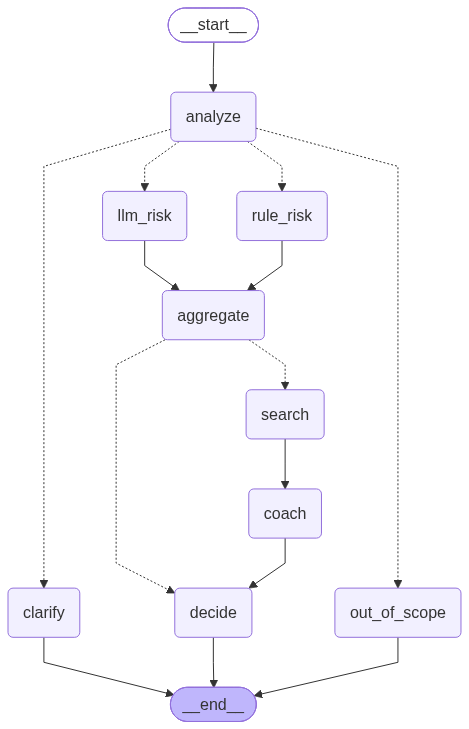

In [1]:
import os
from typing import Literal

from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_core.messages import AIMessage, HumanMessage
from langchain_core.tools import tool
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode
from pydantic import BaseModel, Field
from typing_extensions import TypedDict

load_dotenv()
if not os.getenv("OPENAI_API_KEY"):
    try:
        import streamlit as st

        os.environ["OPENAI_API_KEY"] = st.secrets["OPENAI_API_KEY"]
    except Exception:
        # Streamlit 밖(예: self-check)이거나 secrets 미설정. init_chat_model이 알아서 에러낸다.
        pass

# temperature=0: 위험도 판단은 재현 가능해야 하므로 무작위성을 제거한다.
llm = init_chat_model("openai:gpt-4o", temperature=0)

Risk = Literal["high", "warn", "low"]
# 위험도를 정수로 매핑해 max() 비교가 가능하게 한다. (문자열 비교로는 순서가 틀림)
_RISK_RANK = {"low": 0, "warn": 1, "high": 2}

# rule guardrail로 감지하는 응급 신호 (§7 근거표의 [rule] 항목 중 유·무로 떨어지는 것).
# 전부 근거표상 '높음' 신호이므로, 하나라도 있으면 rule이 high로 강제 상향한다.
RedFlag = Literal[
    "seizure",  # 경련/발작 — AAP·CDC·아이사랑
    "unconscious",  # 의식소실/깨워도 무반응 — AAP·CDC
    "no_urine_8h",  # 소변 8시간 이상 없음(탈수) — CDC
    "bilious_or_bloody_vomit",  # 구토에 담즙(초록)·혈액·커피색 — AAP·아이사랑
    "vomiting_over_24h",  # 구토 24시간 이상 지속 — AAP
    "head_injury_followup",  # 낙상+머리충격 후 의식소실/구토2회↑/각성곤란 — AAP
]

# 응답마다 붙는 실제 상담 자원 연락처. 진단 도구가 아니므로 최종 판단은 항상 사람(의료진/상담센터)에게 연결한다.
CONTACT_FOOTER = (
    "\n\n---\n"
    "📞 **바로 상담할 수 있는 곳**\n"
    "- 야간·주말 응급 상담: **응급의료포털 1339**\n"
    "- 육아 종합 상담: **육아종합지원센터 1577-0756**\n"
    "- 가까운 소아청소년과\n\n"
    "※ 저는 진단·처방을 하지 않는 **교육용 도구**입니다. "
    "실제 판단과 처치는 반드시 의료진과 확인하세요."
)


# ─────────────────────────────────────────────────────────
# 1. State — 노드 사이를 흐르는 공유 데이터
#    병렬 노드(llm_risk, rule_risk)는 서로 다른 필드에 써야 충돌하지 않는다.
# ─────────────────────────────────────────────────────────
class State(TypedDict):
    input: str
    history: str  # 최근 대화 이력 요약 (UI의 session_state에서 주입 — 다중턴 맥락)
    name: str  # 세션 프로필: 아이 이름 (UI에서 주입, 그래프 밖에서 관리)
    month: int  # 세션 프로필: 월령 (UI에서 주입 — analyze가 덮어쓰지 않음)
    in_scope: bool  # analyze 판정: 육아 질문인가?
    needs_clarification: bool  # analyze 판정: 되묻기가 필요한가? (§7)
    clarify_question: str  # 되묻을 질문 문장
    red_flags: list[str]  # analyze가 감지한 응급 신호 (rule 입력)
    temp: float
    symptoms: str
    topic: str
    llm_risk: Risk  # LLM 판단 (병렬 branch 1)
    rule_risk: Risk  # 결정론적 rule 판단 (병렬 branch 2)
    risk: Risk  # aggregate가 max()로 합친 최종값
    source: str  # 근거 검색 결과 원문
    source_status: Literal["found", "not_found"]  # §9 매트릭스 가로축
    answer: str


# ─────────────────────────────────────────────────────────
# 2. 구조화 추출/판단 스키마 — LLM이 자유 텍스트 대신 이 형태로만 답하게 강제
# ─────────────────────────────────────────────────────────
class Extracted(BaseModel):
    """analyze 노드가 자연어에서 뽑아낼 구조. 월령은 세션 프로필에서 오므로 추출하지 않는다."""

    in_scope: bool = Field(
        description="육아/아기 건강 관련 질문이면 true, 아니면 false"
    )
    temp: float = Field(description="체온(섭씨). 언급 없으면 0")
    symptoms: str = Field(description="부모가 호소한 주요 상황/증상 요약")
    topic: Literal["수면", "수유", "발달", "안전", "건강"] = Field(
        description="가장 관련 있는 주제(코칭 관점)"
    )
    red_flags: list[RedFlag] = Field(
        default_factory=list,
        description=(
            "부모 서술에서 명확히 확인되는 응급 신호만 고른다. 추측하지 말 것. "
            "seizure=경련/발작, unconscious=의식소실/깨워도 무반응, "
            "no_urine_8h=소변 8시간 이상 없음, "
            "bilious_or_bloody_vomit=구토에 담즙(초록)·혈액·커피색, "
            "vomiting_over_24h=구토 24시간 이상 지속, "
            "head_injury_followup=낙상/머리충격 후 의식소실·구토 2회 이상·각성곤란"
        ),
    )
    needs_clarification: bool = Field(
        description=(
            "위험도를 가늠하려면 꼭 필요한 핵심 정보(예: 발열을 호소했는데 체온 수치가 없음)가 "
            "빠져 있으면 true. 일상 질문이라 추가 정보가 필요 없으면 false. "
            "정보 부족은 '낮음'의 근거가 아니라 되묻기의 근거다."
        )
    )
    clarify_question: str = Field(
        default="",
        description="needs_clarification가 true일 때, 부모에게 되물을 다정한 한 문장.",
    )


class RiskVerdict(BaseModel):
    """llm_risk 노드의 판단 결과."""

    risk: Risk = Field(description="위험도: high / warn / low 중 하나")
    reason: str = Field(description="판단 근거 한 문장")


# ─────────────────────────────────────────────────────────
# 3. 근거 검색 — 레지스트리는 guides.py로 분리(순수 데이터+함수).
# ─────────────────────────────────────────────────────────
from guides import lookup_guide


@tool
def search_national_guide(month: int, topic: str) -> str:
    """
    월령(개월 수)과 주제로 공신력 있는 기관의 육아 근거 페이지를 조회한다.

    주제는 '수면', '수유', '발달', '안전', '건강' 중 하나여야 한다.
    아이사랑(childcare.go.kr)·CDC·질병관리청 등 공식 자료의 제목과 URL을 돌려준다.
    부모에게 근거 있는 교육 답변을 하기 전, 반드시 이 도구로 공식 자료를 확인하라.
    """
    return lookup_guide(month, topic)


# bind_tools : LLM에게 툴 스키마(이름, 인자, 설명)를 알려주어서 LLM이 "이 툴을 이런 인자로 부르고 싶다"는 의사결정을 메세지에 담을 수 있게.
# 하지만 LLM은 실제로 함수를 실행하지 못함.

# ToolNode : 위 요청을 받아서 진짜로 파이썬 함수를 실행하는 노드.
# LLM이 뱉은 AIMessage.tool_calls를 읽고 -> 해당 함수를 그 인자로 호출, 결과를 ToolMessage로 만들어 state messages에 붙여줌.
_llm_with_search = llm.bind_tools([search_national_guide])
_search_tool_node = ToolNode([search_national_guide])


# ─────────────────────────────────────────────────────────
# 4. 노드 정의
# ─────────────────────────────────────────────────────────
def analyze_node(state: State):
    """
    자연어 입력 → 구조화.
    in_scope(육아 관련 여부), red_flags(응급 신호), needs_clarification(되묻기),
    temp/symptoms/topic을 한 번에 추출한다. 월령은 세션 프로필에서 이미 오므로 추출 안 함.
    """
    history = state.get("history") or "(이전 대화 없음)"
    result = llm.with_structured_output(Extracted).invoke(
        "너는 부모의 말을 구조화해 추출하는 분석기다. 아래 '이전 대화'와 '이번 입력'을 "
        "함께 읽고, 두 곳의 정보를 모두 반영해 판단하라. 이전 대화에서 이미 나온 정보는 "
        "다시 묻지 마라.\n"
        f"아이 개월수: {state['month']}개월 (이미 알고 있으니 절대 되묻지 마라).\n"
        "육아·아기 건강과 무관한 질문(제품 추천, 일반 상식 등)이면 in_scope=false로 판정하라. "
        "응급 신호(red_flags)는 서술에서 '명확히 확인되는' 것만 고르고 추측하지 마라. "
        "needs_clarification은 정말로 위험도를 가늠할 수 없을 때만 true로 하라. "
        "개월수·이전 대화로 이미 충분히 판단 가능한 일상 발달/수면/수유 질문은 되묻지 말고 "
        "false로 두고 바로 답하라. true면 되물을 질문을 clarify_question에 적어라.\n"
        f"── 이전 대화 ──\n{history}\n"
        f"── 이번 입력 ──\n{state['input']}"
    )
    return {
        "in_scope": result.in_scope,
        "temp": result.temp,
        "symptoms": result.symptoms,
        "topic": result.topic,
        "red_flags": list(result.red_flags),
        "needs_clarification": result.needs_clarification,
        "clarify_question": result.clarify_question,
    }


def clarify_node(state: State):
    """
    정보 부족 시 되묻기. 위험 판단으로 넘어가지 않고 질문을 답으로 돌려준다.
    """
    child = state.get("name") or "아이"
    q = state.get("clarify_question") or "조금만 더 자세히 알려주실 수 있을까요?"
    answer = (
        f"조금 더 정확히 도와드리기 위해 여쭤볼게요. 🙂\n\n"
        f"**{q}**\n\n"
        f"{child}의 상황을 알려주시면 위험도를 살펴보고 안내해 드릴게요."
    )
    return {"answer": answer + CONTACT_FOOTER}


def llm_risk_node(state: State):
    """
    LLM이 맥락을 읽어 위험도를 판단 (병렬 branch 1).

    수치화 불가한 [LLM] 참고신호(축 처짐·호흡 이상·눈맞춤 안 됨 등)를 여기서 감지한다.
    진단이 아니라 '병원 상담이 필요한 신호인지'를 보수적으로 가늠한다.
    """
    verdict = llm.with_structured_output(RiskVerdict).invoke(
        "너는 초보 부모를 돕는 육아 교육 코치다. 진단은 하지 않는다. "
        "부모의 서술에서 '지금 병원 상담이 필요한 신호'가 있는지를 보수적으로 가늠하라. "
        "과잉경고(양치기소년)와 위험누락을 모두 피하라. 애매하면 한 단계 높게 보되, "
        "다음은 특별한 동반 신호가 없으면 low로 보라: 수면 패턴 변화(자주 깸·낮잠 거부), "
        "평소보다 조금 덜 먹음, 월령별 발달 걱정(뒤집기·앉기 등), 이유식 거부, "
        "힘들어하지 않는 변비. "
        "반대로 축 처짐·수유 거부·호흡 이상(가쁨·청색증·늑골 함몰)·눈맞춤 안 됨·"
        "탈수 정성징후(입 마름·눈물 없음·소천문 함몰) 같은 동반 신호가 있으면 위험도를 올려라. "
        "위험도를 high/warn/low 중 하나로 답하라.\n"
        f"개월수: {state['month']}, 체온: {state['temp']}℃, 상황: {state['symptoms']}"
    )
    return {"llm_risk": verdict.risk}


def rule_risk_node(state: State):
    """
    근거 확정된 결정론적 rule guardrail (병렬 branch 2). 안전측 최소 위험도 강제 상향.

    근거표의 [rule] 신호를 코드화. 신호는 OR 결합(하나라도 참이면 발동).
    - red_flags(경련·의식소실·소변8h·담즙/혈액구토·구토24h·낙상후) → 전부 high 신호
    - 발열 월령 밴드 (AAP/CDC)
    ponytail: 체온은 직장 기준 가정(측정부위 정규화는 defer).
    """
    month = state["month"]
    temp = state.get("temp", 0.0)
    red_flags = state.get("red_flags") or []

    if red_flags:  # 근거표상 전부 '높음' 신호이므로 하나라도 있으면 high
        risk: Risk = "high"
    elif 0 <= month <= 3 and temp >= 38.0:  # AAP: 3개월(90일) 이하 38℃↑
        risk = "high"
    elif temp >= 40.0:  # CDC: 전월령 40℃↑
        risk = "high"
    elif 3 < month <= 6 and temp >= 38.3:  # AAP: 3~6개월 38.3℃↑
        risk = "warn"
    elif month > 6 and temp >= 39.4:  # AAP: 6개월↑ 39.4℃↑
        risk = "warn"
    else:
        risk = "low"
    return {"rule_risk": risk}


def aggregate_node(state: State):
    """
    두 판단 중 더 높은 위험도를 채택 (finalRisk = max(llm, rule)).

    핵심 안전 설계: 교육형으로 톤은 부드러워져도 이 안전 바닥은 절대 낮추지 않는다.
    LLM이 실수로 낮게 봐도 rule이 강제한 최소선이 max()로 살아남는다.
    """
    final = max(state["llm_risk"], state["rule_risk"], key=_RISK_RANK.get)
    return {"risk": final}


def search_node(state: State):
    """
    공식 근거 조회 (warn/low 경로) — ReAct 루프.

    LLM에게 search 도구를 쥐여주고(bind_tools) 스스로 호출하게 한 뒤,
    ToolNode로 실제 실행해 결과를 얻는다. workflow와 agent의 차이를 드러내는 지점:
    여기서만 '무슨 도구를 어떻게 호출할지'를 LLM이 결정한다.
    ponytail: 단일 왕복(1회 tool 호출)으로 제한 — 근거 조회는 1회면 충분,
    무한 ReAct 루프·비용을 막는다. add when 다단계 근거 종합이 필요해질 때.
    """
    ai: AIMessage = _llm_with_search.invoke(
        [
            HumanMessage(
                f"개월수 {state['month']}개월, 주제 '{state['topic']}'에 맞는 "
                f"공식 육아 근거를 search_national_guide 도구로 조회해줘."
            )
        ]
    )
    if not ai.tool_calls:
        # LLM이 도구를 안 불렀으면 근거 없이 진행 (침묵 대신 not_found로)
        return {"source": "NOT_FOUND", "source_status": "not_found"}

    tool_result = _search_tool_node.invoke({"messages": [ai]})
    source = tool_result["messages"][-1].content
    status = "not_found" if source.strip() == "NOT_FOUND" else "found"
    return {"source": source, "source_status": status}


def coach_node(state: State):
    """주제(topic)를 관점(lens)으로 쓰는 단일 코칭 노드 (근거 있는 low/warn).

    독립된 5개 노드가 아니라, 프롬프트에 topic을 주입해 관점만 바꾼다.
    search 뒤에 실행되므로 state['source']·source_status가 채워져 있고, 이를 반영한다.
    """
    child = state.get("name") or "아이"
    found = state.get("source_status") == "found"

    if state["risk"] == "warn":
        tone = "위험도는 '주의'다. 오늘 중 소아과 방문을 권하는 톤으로, 2번 위험도 판단에서 이를 명확히 하라."
    else:
        tone = "위험도는 '낮음'이다. 집에서 관찰 가능하다는 안심되는 톤으로 답하라."

    if found:
        source_line = (
            f"5번 섹션에는 아래 '참고 근거'의 출처(기관명·URL)를 반드시 명시하라.\n"
            f"참고 근거: {state.get('source')}"
        )
    else:
        # 근거 없음 — 없는 출처를 지어내지 말 것
        source_line = (
            "확인된 공식 자료가 없다. 특정 기관을 출처로 지어내지 말고, "
            "'공식 문서에 특정 기준이 없다'는 점을 밝힌 뒤 일반적인 안내만 하라."
        )

    answer = llm.invoke(
        "너는 초보 부모를 돕는 육아 교육 코치다. 진단·처방은 하지 않고, "
        "부모가 스스로 판단하도록 교육한다. 아래 상황을 다음 7단 구조로 한국어로 답하라. "
        "각 단계에 이모지 제목을 붙여라:\n"
        "1) 📋 지금 상황  2) 🔎 위험도 판단  3) ⚡ 지금 당장 할 일  "
        "4) 🚫 하지 말아야 할 일  5) 📖 왜 그런지 (근거 포함)  "
        "6) 👁 앞으로 관찰할 기준  7) 🏥 병원 상담이 필요한 신호\n"
        f"{tone}\n"
        f"{source_line}\n"
        f"아이 이름: {child} (자연스럽게 이름을 불러 개인화하라)\n"
        f"관점(주제): {state['topic']}\n"
        f"개월수: {state['month']}, 상황: {state['symptoms']}"
    ).content
    return {"answer": answer}


def decide_node(state: State):
    """최종 응답 확정 — 소스×위험도 매트릭스. 연락처를 항상 덧붙인다.

    high: 근거 유무 무관 즉시 병원 안내.
    warn/low: coach가 만든 7단 answer를 쓰되, 근거 없음이면 고지 문구를 앞에 붙인다.
    """
    risk = state["risk"]
    source_status = state.get("source_status", "not_found")
    child = state.get("name") or "아이"

    if risk == "high":
        answer = (
            f"🚨 **지금 바로 소아청소년과 또는 응급 상담에 연락하세요.**\n\n"
            f"{child}의 '{state.get('symptoms', '현재')}' 상황은 즉시 전문가 확인이 "
            f"필요한 신호로 보입니다. 저는 진단을 하지 않으며, 지체 없이 아래 연락처로 "
            f"상담하시길 권합니다."
        )
        return {"answer": answer + CONTACT_FOOTER}

    # warn/low — coach가 생성한 7단 교육 답변
    body = state.get("answer", "")

    if source_status == "not_found":
        if risk == "warn":
            notice = (
                "ℹ️ 확인된 공식 자료를 찾지 못했어요. 아래는 일반적인 안내이며, "
                "**주의가 필요한 상황이니 오늘 중 소아과 상담을 권해요.**\n\n"
            )
        else:  # low + not_found : 침묵 대신 고지 후 일반 안내
            notice = (
                "ℹ️ 공식 문서엔 이 상황에 대한 특정 기준이 없지만, "
                "일반적으로는 아래와 같이 안내드려요.\n\n"
            )
        body = notice + body

    return {"answer": body + CONTACT_FOOTER}


def out_of_scope_node(state: State):
    """육아 무관 질문 거절. 정체성을 재확인한다."""
    answer = (
        "🍼 저는 **초보 부모를 위한 육아 교육 코치**예요.\n\n"
        "아기의 수면·수유·발달·안전·건강 신호처럼 육아와 관련된 고민을 도와드릴 수 있어요. "
        "그 외 주제(제품 추천, 일반 상식 등)는 제 역할 범위 밖이라 도와드리기 어려워요.\n\n"
        '예: "우리 애 2개월인데 열이 나요", "7개월인데 밤에 자주 깨요" 처럼 물어봐 주세요!'
    )
    return {"answer": answer + CONTACT_FOOTER}


# ─────────────────────────────────────────────────────────
# 5. 라우팅 함수 (조건부 edge)
# ─────────────────────────────────────────────────────────
def route_clarify(state: State):
    """
    analyze 직후 첫 분기: 정보가 부족하면 되묻고, 충분하면 다음 분기로.
    """
    return "clarify" if state.get("needs_clarification") else "proceed"


def route_scope(state: State):
    """
    육아 질문이면 두 위험판단으로 fan-out(병렬), 아니면 거절 노드로.
    리스트를 반환하면 LangGraph가 그 노드들을 동시에(병렬) 실행한다.
    """
    return ["llm_risk", "rule_risk"] if state["in_scope"] else "out_of_scope"


def route_after_analyze(state: State):
    """
    analyze 직후 실제 분기: clarify > out_of_scope > 병렬 위험판단 순으로 판정.

    route_clarify와 route_scope를 합쳐 하나의 조건부 edge로 쓴다
    (LangGraph는 노드당 조건부 edge 하나만 걸 수 있으므로).

    안전 우선: rule이 이미 위험 신호(red_flags·발열 밴드)를 잡았다면 되묻지 않는다.
    명백한 고위험(예: 2개월 39℃)을 '측정부위가 궁금해서' 되묻어 지연시키면 위험하다.
    """
    if (
        route_clarify(state) == "clarify"
        and rule_risk_node(state)["rule_risk"] == "low"
    ):
        return "clarify"
    return route_scope(state)


def route_by_risk(state: State):
    """
    aggregate 직후: 위험도별 분기.

    high는 검색을 기다리지 않고 즉시 안내. warn/low는 근거 검색 후 7단 코칭으로.
    """
    return "decide" if state["risk"] == "high" else "search"


# ─────────────────────────────────────────────────────────
# 6. 그래프 조립
# ─────────────────────────────────────────────────────────
def build_graph():
    builder = StateGraph(State)
    builder.add_node("analyze", analyze_node)
    builder.add_node("clarify", clarify_node)
    builder.add_node("out_of_scope", out_of_scope_node)
    builder.add_node("llm_risk", llm_risk_node)
    builder.add_node("rule_risk", rule_risk_node)
    builder.add_node("aggregate", aggregate_node)
    builder.add_node("search", search_node)
    builder.add_node("coach", coach_node)
    builder.add_node("decide", decide_node)

    builder.add_edge(START, "analyze")

    # analyze 직후: 되묻기 / 범위 밖 / 병렬 위험판단 fan-out
    builder.add_conditional_edges(
        "analyze",
        route_after_analyze,
        ["clarify", "out_of_scope", "llm_risk", "rule_risk"],
    )
    builder.add_edge("clarify", END)
    builder.add_edge("out_of_scope", END)

    # fan-in: 두 위험판단이 모두 끝나면 aggregate
    builder.add_edge("llm_risk", "aggregate")
    builder.add_edge("rule_risk", "aggregate")

    # 위험도 분기: high는 즉시 decide, warn/low는 search로
    builder.add_conditional_edges(
        "aggregate",
        route_by_risk,
        {"decide": "decide", "search": "search"},
    )
    builder.add_edge("search", "coach")  # warn/low: 근거 조회 후 7단 코칭
    builder.add_edge("coach", "decide")  # 코칭 답변을 decide가 §9로 마무리
    builder.add_edge("decide", END)
    return builder.compile()


graph = build_graph()

graph